In [8]:
import pandas as pd

df = pd.read_csv("/Play_tenis.txt")


In [17]:
df1 = df.to_csv("/Play_tenis.csv")



In [18]:
df2 = pd.read_csv("/Play_tenis.csv")
df2.to_csv("/Play_tenis_converted.txt", index=False,sep = "\t")

In [34]:
df2.drop(columns=["Unnamed: 0"], inplace=True)

In [44]:
# Remove extra spaces from column names and values

df2.columns = df2.columns.str.strip()

for column in df2.columns:
    df2[column] = df2[column].astype(str).str.strip()

In [45]:
# Assign a unique number to each attribute-value pair

mapping = {}
num = 1

for column in df2.columns:
    for value in df2[column].dropna().unique():
        pair = f"{column}={value}"
        mapping[pair] = num
        num += 1

mapping

{'Outlook=Sunny': 1,
 'Outlook=Overcast': 2,
 'Outlook=Rain': 3,
 'Temperature=Hot': 4,
 'Temperature=Mild': 5,
 'Temperature=Cool': 6,
 'Humidity=High': 7,
 'Humidity=Normal': 8,
 'Wind=Weak': 9,
 'Wind=Strong': 10,
 'PlayTennis=No': 11,
 'PlayTennis=Yes': 12}

In [47]:
# Convert each row into a transaction of numerical values

transactions = []

for _, row in df2.iterrows():
    transaction = []

    for column in df2.columns:
        pair = f"{column}={row[column]}"
        transaction.append(mapping[pair])

    transactions.append(transaction)

transactions

[[1, 4, 7, 9, 11],
 [1, 4, 7, 10, 11],
 [2, 4, 7, 9, 12],
 [3, 5, 7, 9, 12],
 [3, 6, 8, 9, 12],
 [3, 6, 8, 10, 11],
 [2, 6, 8, 10, 12],
 [1, 5, 7, 9, 11],
 [1, 6, 8, 9, 12],
 [3, 5, 8, 9, 12],
 [1, 5, 8, 10, 12],
 [2, 5, 7, 10, 12],
 [2, 4, 8, 9, 12],
 [3, 5, 7, 10, 11]]

In [48]:
# Display each transaction

for i, transaction in enumerate(transactions, 1):
    print(f"Transaction {i}: {transaction}")

Transaction 1: [1, 4, 7, 9, 11]
Transaction 2: [1, 4, 7, 10, 11]
Transaction 3: [2, 4, 7, 9, 12]
Transaction 4: [3, 5, 7, 9, 12]
Transaction 5: [3, 6, 8, 9, 12]
Transaction 6: [3, 6, 8, 10, 11]
Transaction 7: [2, 6, 8, 10, 12]
Transaction 8: [1, 5, 7, 9, 11]
Transaction 9: [1, 6, 8, 9, 12]
Transaction 10: [3, 5, 8, 9, 12]
Transaction 11: [1, 5, 8, 10, 12]
Transaction 12: [2, 5, 7, 10, 12]
Transaction 13: [2, 4, 8, 9, 12]
Transaction 14: [3, 5, 7, 10, 11]


In [49]:
# Convert transactions into binary format
# The assigned numbers become the column names

binary_data = []

for transaction in transactions:
    row = [0] * len(mapping)

    for value in transaction:
        row[value - 1] = 1

    binary_data.append(row)

binary_df = pd.DataFrame(
    binary_data,
    columns=range(1, len(mapping) + 1)
)

binary_df

,1,2,3,4,5,6,7,8,9,10,11,12
0,1,0,0,1,0,0,1,0,1,0,1,0
1,1,0,0,1,0,0,1,0,0,1,1,0
2,0,1,0,1,0,0,1,0,1,0,0,1
3,0,0,1,0,1,0,1,0,1,0,0,1
4,0,0,1,0,0,1,0,1,1,0,0,1
5,0,0,1,0,0,1,0,1,0,1,1,0
6,0,1,0,0,0,1,0,1,0,1,0,1
7,1,0,0,0,1,0,1,0,1,0,1,0
8,1,0,0,0,0,1,0,1,1,0,0,1
9,0,0,1,0,1,0,0,1,1,0,0,1


In [52]:
# Save the binary dataset

binary_df.to_csv("/Play_tenis_binary.csv", index=False)

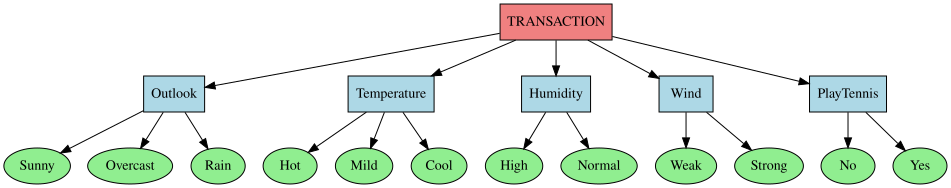

In [53]:
from graphviz import Digraph

dot = Digraph("transaction_graph")

# Main/root node
dot.node(
    "ROOT",
    "TRANSACTION",
    shape="box",
    style="filled",
    fillcolor="lightcoral"
)

# Attributes
for attribute in df2.columns:

    # Unique ID for attribute
    attr_id = f"attr_{attribute}"

    dot.node(
        attr_id,
        attribute,
        shape="box",
        style="filled",
        fillcolor="lightblue"
    )

    # Connect main root -> attribute
    dot.edge("ROOT", attr_id)

    # Values for this attribute
    values = df2[attribute].dropna().unique()

    for value in values:

        # Unique ID for value
        value_id = f"{attribute}_{value}"

        dot.node(
            value_id,
            str(value),
            shape="ellipse",
            style="filled",
            fillcolor="lightgreen"
        )

        # Connect attribute -> value
        dot.edge(attr_id, value_id)

# Display
dot